In [4]:
def suppress_warnings(*args, **kwargs):
    pass

import warnings
warnings.warn = suppress_warnings
warnings.filterwarnings("ignore", category=UserWarning)

import optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import Birch, BisectingKMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.genmod.families.links import Identity
import statsmodels.api as sm

import shap

import shapiq

In [5]:
df = pd.read_csv("../data/train.csv")
TEST_SIZE = 0.1
X = df.drop(columns="critical_temp")
y = df["critical_temp"]
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=1702
    )
y_test = np.clip(y_test, 1e-6, None)
y_train = np.clip(y_train, 1e-6, None)

birch_glm = Birch(n_clusters=10,
                    branching_factor=700,
                    threshold=0.18251719168858943)

cluster_labels_glm = birch_glm.fit_predict(X_train)

unique_clusters_glm = np.unique(cluster_labels_glm)
valid_clusters_glm = [c for c in unique_clusters_glm if c != -1]

In [6]:
import sys
sys.path.append('..//Main_Scripts')
from script_glm_interpretability import *

clustering_glm = Clustering_GLM(clusterer=clone(birch_glm),
                    distribution = sm.families.Gaussian(link=Identity())
    )
clustering_glm.fit(X_train, y_train, X_test)

,clusterer,Birch(branchi...1719168858943)
,distribution,<statsmodels....0027FE87675B0>
,threshold,0.18251719168858943
,branching_factor,700
,n_clusters,10
,compute_labels,True
,copy,'deprecated'


In [7]:
def model_wrapper_glm(x):
    return clustering_glm.predict(x).reshape(-1)

explanations = []
explainer = shapiq.TabularExplainer(
    model=model_wrapper_glm,
    data=X.to_numpy(),
    index="SII",
    max_order=2,
    approximator="montecarlo"
)

In [ ]:
from joblib import Parallel, delayed

X_np = X.to_numpy()
X_test_np = X_test.to_numpy()

def explain_instance(x):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        return explainer.explain(x=x, budget=5096)
    
explanations = Parallel(n_jobs=-1)(
    delayed(explain_instance)(x)
    for x in X_test_np
    )

In [ ]:
values = np.array([exp.values for exp in explanations])
mean_values = values.mean(axis=0)
mean_values_sorted = np.sort(np.array(mean_values))[::-1]

idxs = np.argsort(mean_values)[::-1]
interactions  = list(explanations[0].interactions.keys())
interactions_sorted = [str(interactions[i]) for i in idxs]

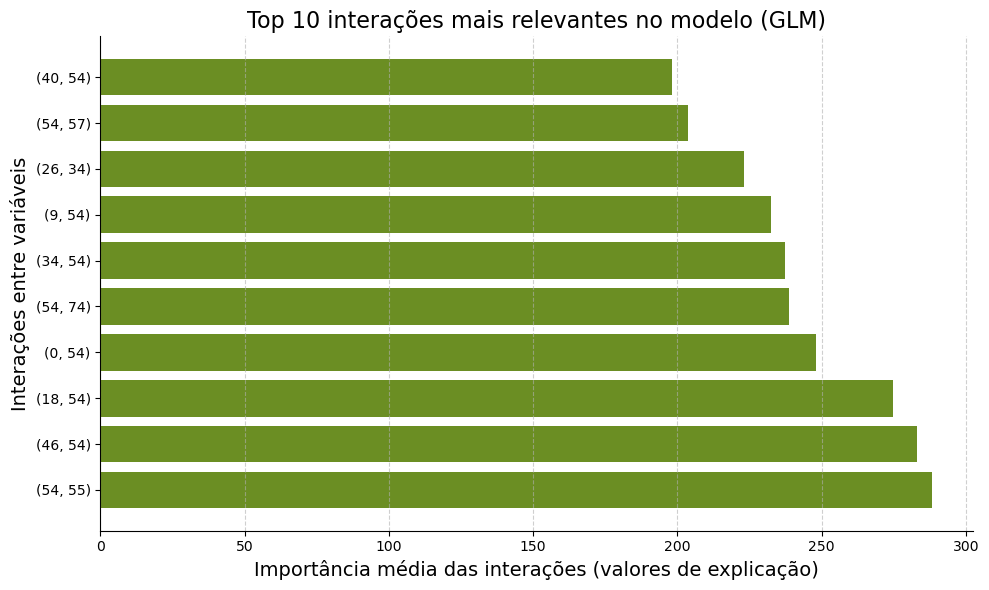

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(interactions_sorted[:10], mean_values_sorted[:10], color="olivedrab")

plt.xlabel("Importância média das interações (valores de explicação)", fontsize=14)
plt.ylabel("Interações entre variáveis", fontsize=14)

plt.title("Top 10 interações mais relevantes no modelo (GLM)", fontsize=16)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("interactions_values_glm_montecarlo.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
bkmeans_gam = BisectingKMeans(n_clusters=6,
                            bisecting_strategy="largest_cluster",
                            random_state=1203)
cluster_labels_gam = bkmeans_gam.fit_predict(X_train)

unique_clusters = np.unique(cluster_labels_gam)
valid_clusters = [c for c in unique_clusters if c != -1]

In [ ]:
import sys
sys.path.append('..//Main_Scripts')

from script_gam_interpretability import *

clustering_gam = Clustering_GAM(clone(bkmeans_gam), "normal", "identity", 25, 1.402388644873421)

clustering_gam.fit(X_train, y_train, X_test)

,clusterer,BisectingKMea...om_state=1203)
,distribution,'normal'
,link,'identity'
,n_splines,25
,lam,1.402388644873421
,n_clusters,6
,init,'random'
,n_init,1
,random_state,1203
,max_iter,300
,verbose,0


In [ ]:
def model_wrapper_gam(x):
    return clustering_gam.predict(x).reshape(-1)

explanations_gam = []
explainer_gam = shapiq.TabularExplainer(
    model=model_wrapper_gam,
    data=X.to_numpy(),
    index="SII",
    max_order=2,
    approximator="montecarlo"

)

In [ ]:
def explain_instance_gam(x):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        return explainer_gam.explain(x=x, budget=5096)

explanations_gam = Parallel(n_jobs=-1)(
    delayed(explain_instance_gam)(x)
    for x in X_test_np
)

In [ ]:
values_gam = np.array([exp.values for exp in explanations_gam])
mean_values_gam = values_gam.mean(axis=0)
mean_values_sorted_gam = np.sort(np.array(mean_values_gam))[::-1]

idxs_gam = np.argsort(mean_values_gam)[::-1]
interactions_gam  = list(explanations_gam[0].interactions.keys())
interactions_sorted_gam = [str(interactions_gam[i]) for i in idxs_gam]

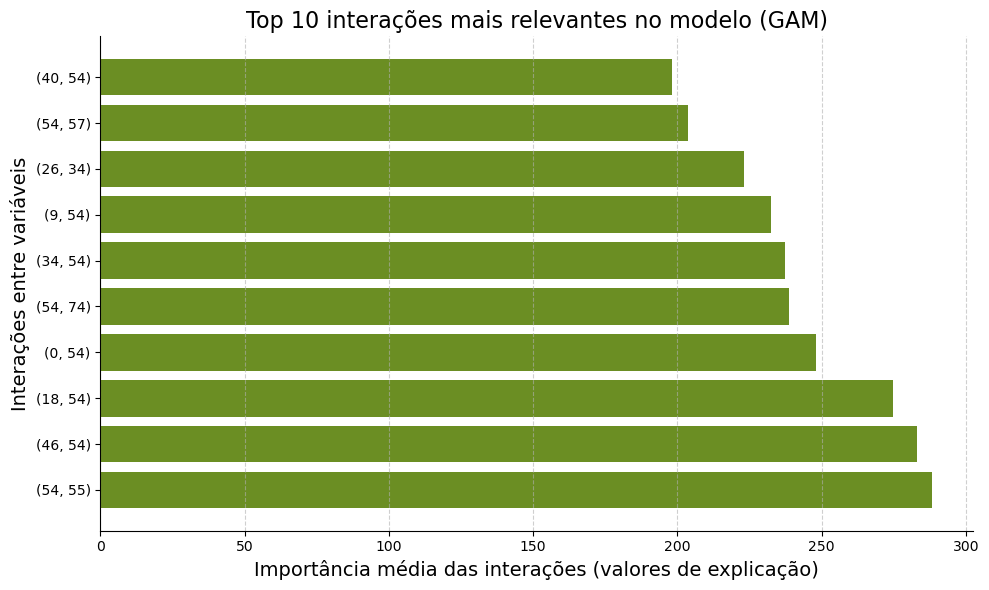

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(interactions_sorted_gam[:10], mean_values_sorted_gam[:10], color="olivedrab")

plt.xlabel("Importância média das interações (valores de explicação)", fontsize=14)
plt.ylabel("Interações entre variáveis", fontsize=14)

plt.title("Top 10 interações mais relevantes no modelo (GAM)", fontsize=16)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("interactions_values_gam_montecarlo.png", dpi=600, bbox_inches='tight')
plt.show()